In [ ]:
!pip install --quiet \
    requests beautifulsoup4 lxml \
    praw youtube-comment-downloader \
    pandas tqdm openpyxl

print("Done.")

# Re-run this cell to ensure all packages are installed and available.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 18.9 MB/s eta 0:00:00
Done.


In [ ]:
import os
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(f"{DATA_DIR}/partial", exist_ok=True)

# ---------- Skytrax ----------
SKYTRAX_AIRLINES = [
    "emirates","qatar-airways","singapore-airlines","cathay-pacific",
    "etihad-airways","ana-all-nippon-airways","japan-airlines","eva-air",
    "korean-air","thai-airways","malaysia-airlines","turkish-airlines",
    "indigo-airlines","air-india","vistara","spicejet","goair",
    "delta-air-lines","united-airlines","american-airlines","southwest-airlines",
    "jetblue-airways","alaska-airlines","spirit-airlines","frontier-airlines",
    "british-airways","lufthansa","klm-royal-dutch-airlines","air-france",
    "swiss-international-air-lines","virgin-atlantic","ryanair","easyjet",
    "qantas-airways","air-new-zealand","aeromexico","latam-airlines",
]
SKYTRAX_AIRPORTS = [
    "bengaluru-airport","delhi-airport","mumbai-airport","hyderabad-airport",
    "chennai-airport","kolkata-airport",
    "singapore-changi-airport","hong-kong-airport","incheon-airport",
    "tokyo-haneda-airport","tokyo-narita-airport","bangkok-suvarnabhumi-airport",
    "kuala-lumpur-airport",
    "dubai-airport","doha-airport","abu-dhabi-airport","istanbul-airport",
    "london-heathrow-airport","london-gatwick-airport","frankfurt-airport",
    "amsterdam-schiphol-airport","paris-cdg-airport","zurich-airport",
    "los-angeles-airport","john-f-kennedy-airport","san-francisco-airport",
    "chicago-ohare-airport","atlanta-hartsfield-jackson-airport",
    "sydney-airport","melbourne-airport",
]
SKYTRAX_PAGES_PER_TARGET = 15      # 15 pages × 10 reviews = up to 150 per target
SKYTRAX_DELAY = 1.5

# ---------- Reddit ----------
REDDIT_SUBS_PASSENGERS = [
    "flying","travel","delta","united","AmericanAirlines",
    "southwestairlines","jetblue","BritishAirways","Emirates",
    "IndianAviation","TravelHacks","onebag","travel_tips",
]
REDDIT_SUBS_OPERATIONS = [
    "cabincrew","flightattendants","aviation","AirlinePilots","ATC",
    "AirportEmployees","airlineemployees",
]
REDDIT_SEARCH_TERMS = [
    "boarding chaos","check in queue","kiosk broken","bag drop",
    "lost baggage","damaged bag","delayed bag",
    "rebooking nightmare","irregular operations","IROPS","missed connection",
    "stranded","cancelled flight","compensation",
    "crew scheduling","rostering","fatigue","crew swap",
    "gate agent","ground handling","ramp",
    "lounge access","priority pass","upgrade",
    "seat selection","legroom","middle seat",
    "wifi onboard","ife broken","meal special",
    "app booking","mobile boarding pass","customer service",
]
REDDIT_POSTS_PER_QUERY = 25
REDDIT_COMMENTS_PER_POST = 40

# ---------- YouTube ----------
YOUTUBE_QUERIES = [
    "airport experience review","worst airline experience","best airline experience",
    "flight attendant day in the life","pilot life airline",
    "boarding process problems","airline check in nightmare",
    "lost luggage airline","damaged baggage airline",
    "airline IROPS disruption","flight cancellation rebooking",
    "airline customer service review","airline lounge review",
    "first class review","economy class review","premium economy review",
    "long haul flight review","red eye flight experience",
    "ground staff airport","gate agent rude",
    "airport security tips","tsa precheck experience",
    "airline app review","mobile boarding pass problems",
    "airline seat selection","legroom complaint",
    "airline meal review","onboard wifi review",
    "airline mishandled bag","compensation EC261",
    "Indian airport experience","Dubai airport experience",
]
YOUTUBE_VIDEOS_PER_QUERY = 6
YOUTUBE_COMMENTS_PER_VIDEO = 400

# ---------- Output ----------
OUTPUT_XLSX = f"{DATA_DIR}/flying_reviews.xlsx"

print(f"Targets: {len(SKYTRAX_AIRLINES)} airlines, {len(SKYTRAX_AIRPORTS)} airports, "
      f"{len(REDDIT_SUBS_PASSENGERS)+len(REDDIT_SUBS_OPERATIONS)} subreddits, "
      f"{len(YOUTUBE_QUERIES)} YouTube queries.")


Targets: 37 airlines, 30 airports, 20 subreddits, 32 YouTube queries.


In [ ]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

def make_session():
    s = requests.Session()
    retry = Retry(
        total=4, backoff_factor=1.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["GET", "HEAD"]),
        respect_retry_after_header=True,
    )
    s.mount("https://", HTTPAdapter(max_retries=retry))
    s.mount("http://", HTTPAdapter(max_retries=retry))
    s.headers.update({
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"
        ),
        "Accept-Language": "en-US,en;q=0.9",
    })
    return s

HTTP = make_session()
print("HTTP session ready.")


HTTP session ready.


In [ ]:
import time, re, os
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm
import pandas as pd

SKYTRAX_PARTIAL_DIR = f"{DATA_DIR}/partial/skytrax"
os.makedirs(SKYTRAX_PARTIAL_DIR, exist_ok=True)

def _parse_skytrax_card(card):
    out = {
        "rating": None, "title": None, "author": None, "country": None,
        "date": None, "verified": False, "traveller_type": None,
        "seat_type": None, "route": None, "text": None,
    }
    rn = card.select_one(".rating-10 span[itemprop='ratingValue']")
    if rn:
        try: out["rating"] = int(rn.get_text(strip=True))
        except ValueError: pass

    t = card.select_one("h2.text_header")
    if t: out["title"] = t.get_text(strip=True).strip('"')

    a = card.select_one("span[itemprop='name']")
    if a: out["author"] = a.get_text(strip=True)

    c = card.select_one("h3.text_sub_header")
    if c:
        m = re.search(r"\(([^)]+)\)", c.get_text())
        if m: out["country"] = m.group(1).strip()

    d = card.select_one("time")
    if d and d.has_attr("datetime"):
        out["date"] = d["datetime"]

    body = card.select_one("div.text_content")
    if body:
        text = body.get_text(" ", strip=True)
        out["verified"] = "Trip Verified" in text or "Verified Review" in text
        text = re.sub(r"^(✅\s*)?Trip Verified\s*\|\s*", "", text)
        text = re.sub(r"^Not Verified\s*\|\s*", "", text)
        out["text"] = text.strip()

    for row in card.select("table.review-ratings tr"):
        h = row.select_one("td.review-rating-header")
        v = row.select_one("td.review-value")
        if not h or not v: continue
        hk = h.get_text(strip=True).lower()
        vk = v.get_text(strip=True)
        if "traveller" in hk: out["traveller_type"] = vk
        elif "seat" in hk: out["seat_type"] = vk
        elif "route" in hk: out["route"] = vk
    return out

def _scrape_skytrax_target(slug, target_type, pages, delay):
    base = "https://www.airlinequality.com"
    rows = []
    for page in range(1, pages + 1):
        url = f"{base}/{target_type}-reviews/{slug}/page/{page}/?sortby=post_date%3ADesc&pagesize=10"
        try:
            r = HTTP.get(url, timeout=25)
            if r.status_code != 200:
                break
            soup = BeautifulSoup(r.text, "lxml")
            cards = soup.select("article.list-item.media.position-content")
            if not cards:
                break
            for card in cards:
                row = _parse_skytrax_card(card)
                if not row.get("text"):
                    continue
                row["source"] = "skytrax"
                row["source_target"] = slug
                row["source_target_type"] = target_type
                rows.append(row)
            time.sleep(delay)
        except Exception:
            continue
    return rows

def scrape_skytrax(airlines, airports, pages, delay):
    all_rows = []
    targets = [(s, "airline") for s in airlines] + [(s, "airport") for s in airports]
    for slug, t_type in tqdm(targets, desc="Skytrax targets"):
        partial_path = f"{SKYTRAX_PARTIAL_DIR}/{t_type}__{slug}.csv"
        if os.path.exists(partial_path):
            # Resume: re-use what's on disk
            try:
                df = pd.read_csv(partial_path)
                all_rows.extend(df.to_dict(orient="records"))
                continue
            except Exception:
                pass
        try:
            rows = _scrape_skytrax_target(slug, t_type, pages, delay)
            if rows:
                pd.DataFrame(rows).to_csv(partial_path, index=False)
                all_rows.extend(rows)
        except Exception as e:
            print(f"  ! {t_type}/{slug} failed: {e}")
            continue
    return all_rows

print("Skytrax scraper ready.")


Skytrax scraper ready.


In [ ]:
from itertools import islice
from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_POPULAR

YT_PARTIAL_DIR = f"{DATA_DIR}/partial/youtube"
os.makedirs(YT_PARTIAL_DIR, exist_ok=True)

def _yt_search_video_ids(query, max_results=6):
    url = "https://www.youtube.com/results"
    try:
        r = HTTP.get(url, params={"search_query": query}, timeout=20)
        ids = re.findall(r'"videoId":"([a-zA-Z0-9_-]{11})"', r.text)
        seen, out = set(), []
        for vid in ids:
            if vid not in seen:
                seen.add(vid); out.append(vid)
            if len(out) >= max_results: break
        return out
    except Exception:
        return []

def scrape_youtube(queries, videos_per_query, comments_per_video):
    downloader = YoutubeCommentDownloader()
    all_rows = []

    for query in tqdm(queries, desc="YouTube queries"):
        video_ids = _yt_search_video_ids(query, videos_per_query)
        for vid in video_ids:
            partial_path = f"{YT_PARTIAL_DIR}/{vid}.csv"
            if os.path.exists(partial_path):
                try:
                    df = pd.read_csv(partial_path)
                    all_rows.extend(df.to_dict(orient="records"))
                    continue
                except Exception:
                    pass

            url = f"https://www.youtube.com/watch?v={vid}"
            video_rows = []
            try:
                comments = downloader.get_comments_from_url(url, sort_by=SORT_BY_POPULAR)
                for c in islice(comments, comments_per_video):
                    text = c.get("text", "").strip()
                    if len(text) < 20: continue
                    video_rows.append({
                        "source": "youtube",
                        "source_target": vid,
                        "source_target_type": "video",
                        "search_query": query,
                        "title": query,
                        "text": text,
                        "author": c.get("author", ""),
                        "date": c.get("time", ""),
                        "score": c.get("votes", 0),
                        "url": url,
                    })
            except Exception:
                continue

            if video_rows:
                pd.DataFrame(video_rows).to_csv(partial_path, index=False)
                all_rows.extend(video_rows)
    return all_rows

print("YouTube scraper ready.")

YouTube scraper ready.


In [ ]:
REDDIT_CLIENT_ID = ""
REDDIT_CLIENT_SECRET = ""
REDDIT_USER_AGENT = ""

RUN_SKYTRAX = True
RUN_REDDIT  = bool(REDDIT_CLIENT_ID and REDDIT_CLIENT_SECRET)
RUN_YOUTUBE = True

skytrax_rows, reddit_rows, youtube_rows = [], [], []

if RUN_SKYTRAX:
    print("\n=== SKYTRAX ===")
    try:
        skytrax_rows = scrape_skytrax(
            SKYTRAX_AIRLINES, SKYTRAX_AIRPORTS,
            pages=SKYTRAX_PAGES_PER_TARGET, delay=SKYTRAX_DELAY,
        )
        print(f"-> {len(skytrax_rows):,} reviews")
    except Exception as e:
        print(f"Skytrax fatal: {e}")

if RUN_REDDIT:
    print("\n=== REDDIT ===")
    try:
        reddit_rows = scrape_reddit(
            REDDIT_CLIENT_ID, REDDIT_CLIENT_SECRET, REDDIT_USER_AGENT,
            REDDIT_SUBS_PASSENGERS, REDDIT_SUBS_OPERATIONS, REDDIT_SEARCH_TERMS,
            posts_per_query=REDDIT_POSTS_PER_QUERY,
            comments_per_post=REDDIT_COMMENTS_PER_POST,
        )
        print(f"-> {len(reddit_rows):,} items")
    except Exception as e:
        print(f"Reddit fatal: {e}")
else:
    print("\n=== REDDIT SKIPPED (no credentials) ===")

if RUN_YOUTUBE:
    print("\n=== YOUTUBE ===")
    try:
        youtube_rows = scrape_youtube(
            YOUTUBE_QUERIES,
            videos_per_query=YOUTUBE_VIDEOS_PER_QUERY,
            comments_per_video=YOUTUBE_COMMENTS_PER_VIDEO,
        )
        print(f"-> {len(youtube_rows):,} comments")
    except Exception as e:
        print(f"YouTube fatal: {e}")

total = len(skytrax_rows) + len(reddit_rows) + len(youtube_rows)
print(f"\n=== TOTAL: {total:,} rows ===")


=== SKYTRAX ===


Skytrax targets:   0%|          | 0/67 [00:00<?, ?it/s]

-> 8,738 reviews

=== REDDIT SKIPPED (no credentials) ===

=== YOUTUBE ===


YouTube queries:   0%|          | 0/32 [00:00<?, ?it/s]

-> 22,907 comments

=== TOTAL: 31,645 rows ===


In [ ]:
import glob, pandas as pd

REDDIT_PARTIAL_DIR = f"{DATA_DIR}/partial/reddit"
os.makedirs(REDDIT_PARTIAL_DIR, exist_ok=True)

def _load_partials(directory):
    rows = []
    for f in sorted(glob.glob(f"{directory}/*.csv")):
        try:
            df = pd.read_csv(f)
            rows.extend(df.to_dict(orient="records"))
        except Exception:
            continue
    return rows

# Prefer in-memory results, fall back to partials on disk
if not skytrax_rows:
    skytrax_rows = _load_partials(SKYTRAX_PARTIAL_DIR)
    print(f"Loaded {len(skytrax_rows):,} Skytrax rows from disk")
if not reddit_rows:
    reddit_rows = _load_partials(REDDIT_PARTIAL_DIR)
    print(f"Loaded {len(reddit_rows):,} Reddit rows from disk")
if not youtube_rows:
    youtube_rows = _load_partials(YT_PARTIAL_DIR)
    print(f"Loaded {len(youtube_rows):,} YouTube rows from disk")

skytrax_df = pd.DataFrame(skytrax_rows)
reddit_df  = pd.DataFrame(reddit_rows)
youtube_df = pd.DataFrame(youtube_rows)

# Convert reddit unix timestamp -> readable date
if not reddit_df.empty and "date" in reddit_df.columns:
    reddit_df["date"] = pd.to_datetime(reddit_df["date"], unit="s", errors="coerce")

# Drop exact duplicates (same source + same text)
for df in [skytrax_df, reddit_df, youtube_df]:
    if not df.empty and "text" in df.columns:
        df.drop_duplicates(subset=["source", "text"], inplace=True)

print(f"\nSkytrax: {len(skytrax_df):,}")
print(f"Reddit:  {len(reddit_df):,}")
print(f"YouTube: {len(youtube_df):,}")
print(f"Total:   {len(skytrax_df) + len(reddit_df) + len(youtube_df):,}")

Loaded 0 Reddit rows from disk

Skytrax: 8,614
Reddit:  0
YouTube: 21,607
Total:   30,221


In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

EXCEL_CELL_LIMIT = 32000

def _safe_cell_value(v):
    if pd.isna(v) or v is None:
        return ""
    s = v if isinstance(v, (int, float, bool)) else str(v)
    if isinstance(s, str) and len(s) > EXCEL_CELL_LIMIT:
        s = s[:EXCEL_CELL_LIMIT] + " ...[truncated]"
    return s

def _align_columns(df, wanted):
    if df.empty:
        return pd.DataFrame(columns=wanted)
    for c in wanted:
        if c not in df.columns:
            df[c] = ""
    return df[wanted].copy()

COMBINED_COLS = [
    "source", "source_target", "source_target_type",
    "stakeholder_hint", "title", "rating", "verified",
    "traveller_type", "seat_type", "route",
    "country", "author", "date", "score", "text", "url",
]

frames = []
for df in [skytrax_df, reddit_df, youtube_df]:
    if not df.empty:
        frames.append(_align_columns(df, COMBINED_COLS))
all_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=COMBINED_COLS)
print(f"Combined: {len(all_df):,} rows -> writing Excel...")

# ---- styling ----
HEADER_FILL = PatternFill("solid", start_color="1F3A5F", end_color="1F3A5F")
HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=11)
BODY_FONT   = Font(name="Arial", size=10)
SECTION_FONT = Font(name="Arial", bold=True, size=12, color="1F3A5F")
HEADER_BORDER = Border(bottom=Side(border_style="medium", color="1F3A5F"))

WIDTH_HINTS = {
    "source": 10, "source_target": 24, "source_target_type": 16,
    "stakeholder_hint": 14, "title": 38, "rating": 8, "verified": 9,
    "traveller_type": 16, "seat_type": 14, "route": 24,
    "country": 18, "author": 18, "date": 20, "score": 8,
    "text": 80, "url": 40, "search_query": 28,
}

def _write_df_to_sheet(ws, df, wrap_col="text"):
    if df.empty:
        ws["A1"] = "(no data)"
        ws["A1"].font = BODY_FONT
        return
    cols = list(df.columns)
    for j, col in enumerate(cols, start=1):
        c = ws.cell(row=1, column=j, value=col)
        c.font = HEADER_FONT
        c.fill = HEADER_FILL
        c.alignment = Alignment(horizontal="left", vertical="center")
        c.border = HEADER_BORDER

    for i, (_, row) in enumerate(df.iterrows(), start=2):
        for j, col in enumerate(cols, start=1):
            cell = ws.cell(row=i, column=j, value=_safe_cell_value(row[col]))
            cell.font = BODY_FONT
            if col == wrap_col:
                cell.alignment = Alignment(wrap_text=True, vertical="top")
            else:
                cell.alignment = Alignment(vertical="top")

    for j, col in enumerate(cols, start=1):
        ws.column_dimensions[get_column_letter(j)].width = WIDTH_HINTS.get(col, 16)

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

# ---- workbook ----
wb = Workbook()
wb.remove(wb.active)

# All Reviews
print("  Writing 'All Reviews' sheet...")
ws = wb.create_sheet("All Reviews")
_write_df_to_sheet(ws, all_df)

# Per-source sheets
SOURCE_COLS = {
    "Skytrax": (skytrax_df, [
        "source_target", "source_target_type", "title", "rating",
        "verified", "traveller_type", "seat_type", "route",
        "country", "author", "date", "text",
    ]),
    "Reddit": (reddit_df, [
        "source_target", "stakeholder_hint", "title",
        "author", "date", "score", "text", "url",
    ]),
    "YouTube": (youtube_df, [
        "source_target", "title", "author", "date",
        "score", "text", "url",
    ]),
}
for name, (df, cols) in SOURCE_COLS.items():
    print(f"  Writing '{name}' sheet...")
    sub = _align_columns(df, cols) if not df.empty else pd.DataFrame(columns=cols)
    ws = wb.create_sheet(name)
    _write_df_to_sheet(ws, sub)

# Summary sheet
print("  Writing 'Summary' sheet...")
ws_sum = wb.create_sheet("Summary")
ws_sum["A1"] = "Air-Travel Customer Journey — Scrape Summary"
ws_sum["A1"].font = Font(name="Arial", bold=True, size=14, color="1F3A5F")
ws_sum["A2"] = f"Total rows scraped: {len(all_df):,}"
ws_sum["A2"].font = BODY_FONT

summary_blocks = []
if not all_df.empty:
    by_source = all_df.groupby("source").size().reset_index(name="Reviews")
    by_source.columns = ["Source", "Reviews"]
    summary_blocks.append(("Reviews by source", by_source))

    by_target = (all_df.groupby(["source", "source_target"])
                       .size().reset_index(name="Reviews")
                       .sort_values(["source", "Reviews"], ascending=[True, False]))
    by_target.columns = ["Source", "Target", "Reviews"]
    summary_blocks.append(("Reviews by source × target", by_target))

    if not skytrax_df.empty and "rating" in skytrax_df.columns:
        rs = skytrax_df.dropna(subset=["rating"]).copy()
        if not rs.empty:
            rs["rating"] = pd.to_numeric(rs["rating"], errors="coerce")
            rs = rs.dropna(subset=["rating"])
            avg_rating = (rs.groupby("source_target")
                            .agg(reviews=("rating", "size"),
                                 avg_rating=("rating", "mean"))
                            .reset_index()
                            .sort_values("reviews", ascending=False))
            avg_rating["avg_rating"] = avg_rating["avg_rating"].round(2)
            avg_rating.columns = ["Skytrax target", "Reviews", "Avg rating /10"]
            summary_blocks.append(("Skytrax: avg rating by target", avg_rating))

current_row = 4
for block_title, df in summary_blocks:
    ws_sum.cell(row=current_row, column=1, value=block_title).font = SECTION_FONT
    current_row += 1
    for j, c in enumerate(df.columns, start=1):
        cell = ws_sum.cell(row=current_row, column=j, value=c)
        cell.font = HEADER_FONT
        cell.fill = HEADER_FILL
        cell.alignment = Alignment(horizontal="left", vertical="center")
    current_row += 1
    for _, row in df.iterrows():
        for j, c in enumerate(df.columns, start=1):
            cell = ws_sum.cell(row=current_row, column=j, value=_safe_cell_value(row[c]))
            cell.font = BODY_FONT
        current_row += 1
    current_row += 2

for col_letter, width in [("A", 38), ("B", 24), ("C", 18), ("D", 14)]:
    ws_sum.column_dimensions[col_letter].width = width

wb.save(OUTPUT_XLSX)
size_mb = os.path.getsize(OUTPUT_XLSX) / (1024 * 1024)
print(f"\nSaved -> {OUTPUT_XLSX}")
print(f"Size: {size_mb:.1f} MB")
print(f"Sheets: {wb.sheetnames}")


Combined: 30,221 rows -> writing Excel...
  Writing 'All Reviews' sheet...
  Writing 'Skytrax' sheet...
  Writing 'Reddit' sheet...
  Writing 'YouTube' sheet...
  Writing 'Summary' sheet...

Saved -> /content/data/flying_reviews.xlsx
Size: 11.0 MB
Sheets: ['All Reviews', 'Skytrax', 'Reddit', 'YouTube', 'Summary']


In [ ]:
from google.colab import files
files.download(OUTPUT_XLSX)

# # Alternative: save to Drive instead
# from google.colab import drive
# drive.mount("/content/drive")
# import shutil
# shutil.copy(OUTPUT_XLSX, "/content/drive/MyDrive/flying_reviews.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
!pip install --quiet \
    pandas openpyxl tqdm \
    scikit-learn \
    vaderSentiment \
    sentence-transformers \
    transformers torch accelerate \
    matplotlib seaborn wordcloud

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00
Done.


In [3]:
import torch
if torch.cuda.is_available():
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    DEVICE = 0
else:
    print("⚠️  No GPU. Zero-shot will be very slow on 50k rows.")
    print("   Either: Runtime → Change runtime type → T4 GPU,")
    print("   or set ENABLE_ZERO_SHOT = False in the zero-shot cell.")
    DEVICE = -1


⚠️  No GPU. Zero-shot will be very slow on 50k rows.
   Either: Runtime → Change runtime type → T4 GPU,
   or set ENABLE_ZERO_SHOT = False in the zero-shot cell.


In [4]:
import os
from google.colab import files

# ----- Option A: upload from local machine -----
print("Upload flying_reviews.xlsx (from Notebook 1 output):")
uploaded = files.upload()
INPUT_XLSX = list(uploaded.keys())[0]
print(f"Loaded: {INPUT_XLSX}")

# ----- Option B: read from Drive (uncomment) -----
# from google.colab import drive
# drive.mount("/content/drive")
# INPUT_XLSX = "/content/drive/MyDrive/flying_reviews.xlsx"


Upload flying_reviews.xlsx (from Notebook 1 output):


Saving flying_reviews.xlsx to flying_reviews.xlsx
Loaded: flying_reviews.xlsx


In [5]:
import pandas as pd
df = pd.read_excel(INPUT_XLSX, sheet_name="All Reviews")
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
df.head(3)

Loaded 30,221 rows, 16 columns


,source,source_target,source_target_type,stakeholder_hint,title,rating,verified,traveller_type,seat_type,route,country,author,date,score,text,url
0,skytrax,emirates,airline,NaN,Worst customer service ever,1.0,0.0,Solo Leisure,Economy Class,NaN,New Zealand,S Naik,2026-05-01,NaN,"Like others, having a complete headache gettin...",NaN
1,skytrax,emirates,airline,NaN,"absence of transparency, accountability",1.0,0.0,Family Leisure,Economy Class,Frankfurt to Dubai,Germany,Alina Chernousova,2026-04-30,NaN,"Due to the war situation in the Middle East, I...",NaN
2,skytrax,emirates,airline,NaN,a very disappointing experience,1.0,0.0,Solo Leisure,Economy Class,Lisbon to Bali via Dubai,Indonesia,Edward Quigley,2026-04-08,NaN,I recently booked a flight with Emirates from ...,NaN


In [6]:
import re

def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = re.sub(r"http\S+|www\.\S+", "", t)        # strip URLs
    t = re.sub(r"\s+", " ", t)                      # collapse whitespace
    return t.strip()

df["text_clean"] = df["text"].apply(clean_text)
before = len(df)
df = df[df["text_clean"].str.len() >= 30].reset_index(drop=True)
print(f"Kept {len(df):,} of {before:,} rows after cleaning (≥30 chars).")


Kept 27,475 of 30,221 rows after cleaning (≥30 chars).


In [7]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
tqdm.pandas()

analyzer = SentimentIntensityAnalyzer()

def vader_score(t):
    s = analyzer.polarity_scores(t)
    c = s["compound"]
    label = "positive" if c >= 0.05 else ("negative" if c <= -0.05 else "neutral")
    return pd.Series({"sentiment_compound": c, "sentiment_label": label})

print("Scoring sentiment...")
sent = df["text_clean"].progress_apply(vader_score)
df = pd.concat([df, sent], axis=1)

print("\nSentiment distribution:")
print(df["sentiment_label"].value_counts())

Scoring sentiment...


  0%|          | 0/27475 [00:00<?, ?it/s]


Sentiment distribution:
sentiment_label
positive    14395
negative     8710
neutral      4370
Name: count, dtype: int64


In [8]:
# ============================================================
# FAST ZERO-SHOT CLASSIFICATION (bi-encoder embedding similarity)
# ============================================================
# Replaces the slow NLI cross-encoder with a bi-encoder approach:
#   - NLI does N × K forward passes (50k × 14 = 700k passes, ~25 min on T4)
#   - Bi-encoder does N + K encodes once, then a fast matrix multiply
#     (~10 sec on T4, ~2 min on CPU). Same multi-label output.
#
# Trade-off: bi-encoder accuracy is ~2-5% lower than a strong NLI model on
# benchmark tasks, but for surfacing pain-point clusters in customer reviews
# this is more than good enough — and the 100× speed-up means you can
# iterate on the taxonomy.

ENABLE_ZERO_SHOT = True

# Verbalize labels with rich descriptions — bi-encoders work much better
# with natural-sentence labels than terse phrases.
CATEGORY_DESCRIPTIONS = {
    "Check-in and bag drop":
        "Problems or experience with airline check-in, kiosks, counters, or bag drop at the airport.",
    "Airport security and immigration":
        "Experience going through airport security screening, TSA, passport control, or immigration.",
    "Boarding process":
        "The boarding process at the gate, including queues, zones, gate agents, and jet bridge.",
    "Lounge access and amenities":
        "Airport lounge access, lounge facilities, food, seating, and Priority Pass entry.",
    "Seat comfort and legroom":
        "Aircraft seat comfort, legroom, recline, seat selection, middle seat, or upgrade.",
    "In-flight service food and crew":
        "Cabin crew service, flight attendants, in-flight meals, drinks, and onboard hospitality.",
    "In-flight entertainment and wifi":
        "In-flight entertainment screens, movies, onboard wifi, and connectivity.",
    "Flight delays cancellations and disruptions":
        "Flight delays, cancellations, missed connections, rebooking, IROPS, and compensation.",
    "Lost or damaged baggage":
        "Lost luggage, delayed baggage, damaged bags, baggage claim, and World Tracer issues.",
    "Customer service and complaint handling":
        "Airline customer service quality, complaint handling, refunds, and call centre experience.",
    "Pricing and fees":
        "Ticket pricing, hidden fees, baggage fees, seat selection charges, and fare value.",
    "Mobile app and digital experience":
        "Airline mobile app, website, online booking, mobile boarding pass, and digital check-in.",
    "Loyalty program and rewards":
        "Frequent flyer programs, loyalty status, miles, points, rewards, and elite tiers.",
    "Crew workload and scheduling":
        "Cabin crew or pilot rostering, scheduling, fatigue, trip swaps, and operations workload.",
}
CATEGORIES = list(CATEGORY_DESCRIPTIONS.keys())
DESCRIPTIONS = list(CATEGORY_DESCRIPTIONS.values())

if ENABLE_ZERO_SHOT:
    import torch
    import numpy as np
    from sentence_transformers import SentenceTransformer

    USE_GPU = torch.cuda.is_available()
    device = "cuda" if USE_GPU else "cpu"
    print(f"Device: {device}")

    # Reuse embeddings if cell 17 already ran; otherwise compute now
    reuse = ("embeddings" in dir()
             and isinstance(globals().get("embeddings"), np.ndarray)
             and embeddings.shape[0] == len(df))

    if reuse:
        print(f"Reusing existing embeddings: {embeddings.shape}")
        text_emb = embeddings
        # If cell 17 already loaded the model, reuse it too
        if "emb_model" in dir():
            model = emb_model
        else:
            model = SentenceTransformer(
                "sentence-transformers/all-MiniLM-L6-v2", device=device)
    else:
        print("Loading embedding model (all-MiniLM-L6-v2, ~80MB)...")
        model = SentenceTransformer(
            "sentence-transformers/all-MiniLM-L6-v2", device=device)
        print(f"Encoding {len(df):,} reviews...")
        # fp16 + larger batch on GPU; modest batch on CPU
        if USE_GPU:
            model = model.half()
            batch = 256
        else:
            batch = 64
        texts = [t[:2000] for t in df["text_clean"].tolist()]
        text_emb = model.encode(
            texts, batch_size=batch, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        # Stash for later cells (KMeans) so they don't re-encode
        embeddings = text_emb
        emb_model = model

    print("Encoding category descriptions...")
    label_emb = model.encode(
        DESCRIPTIONS, batch_size=16, show_progress_bar=False,
        convert_to_numpy=True, normalize_embeddings=True,
    )

    # Cosine similarity = dot product because both are L2-normalized.
    # text_emb: (N, D), label_emb: (K, D) -> sims: (N, K)
    print("Computing similarities (matrix multiply)...")
    sims = text_emb @ label_emb.T
    print(f"Similarity matrix: {sims.shape}")

    # ---- Tunable thresholds ----
    # Bi-encoder cosine similarities for short customer-review vs label
    # descriptions tend to live in [0.15, 0.55]. Calibrate on your data:
    # raise THRESHOLD if everything matches everything; lower if nothing matches.
    THRESHOLD = 0.30
    TOP_K_FALLBACK = 1   # always assign at least this many top labels

    top_idx = sims.argmax(axis=1)
    top_score = sims.max(axis=1)
    df["zs_top_category"] = [CATEGORIES[i] for i in top_idx]
    df["zs_top_score"] = top_score.round(3)

    # Multi-label: keep all labels above threshold, but always include top-1
    all_labels_col = []
    for i in range(sims.shape[0]):
        row = sims[i]
        hits = [(CATEGORIES[j], row[j]) for j in range(len(CATEGORIES))
                if row[j] >= THRESHOLD]
        if not hits:
            # fallback: keep top-K
            top_k_idx = row.argsort()[-TOP_K_FALLBACK:][::-1]
            hits = [(CATEGORIES[j], row[j]) for j in top_k_idx]
        hits.sort(key=lambda x: -x[1])
        all_labels_col.append(";".join(name for name, _ in hits))
    df["zs_all_categories"] = all_labels_col

    print("\nTop category distribution:")
    print(df["zs_top_category"].value_counts().head(20))
    print(f"\nScore stats: min={top_score.min():.3f}, "
          f"median={np.median(top_score):.3f}, max={top_score.max():.3f}")
    print(f"% rows with at least one label above threshold: "
          f"{100 * (sims.max(axis=1) >= THRESHOLD).mean():.1f}%")
else:
    df["zs_top_category"] = ""
    df["zs_top_score"] = 0.0
    df["zs_all_categories"] = ""
    print("Zero-shot skipped.")

Device: cpu
Loading embedding model (all-MiniLM-L6-v2, ~80MB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 27,475 reviews...


Batches:   0%|          | 0/430 [00:00<?, ?it/s]

Encoding category descriptions...
Computing similarities (matrix multiply)...
Similarity matrix: (27475, 14)

Top category distribution:
zs_top_category
Check-in and bag drop                          4811
Customer service and complaint handling        3369
In-flight service food and crew                3281
Lounge access and amenities                    2481
Airport security and immigration               1944
Flight delays cancellations and disruptions    1839
Seat comfort and legroom                       1838
Lost or damaged baggage                        1741
In-flight entertainment and wifi               1517
Pricing and fees                               1437
Boarding process                                980
Mobile app and digital experience               865
Loyalty program and rewards                     735
Crew workload and scheduling                    637
Name: count, dtype: int64

Score stats: min=-0.061, median=0.349, max=0.777
% rows with at least one label above thresh

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords as nltk_stopwords

N_TOPICS = 12

# Aviation-specific stopwords on top of English
EXTRA_STOPWORDS = {
    "flight","flights","airline","airlines","airport","airports","plane",
    "fly","flying","flew","trip","time","just","like","really","got",
    "would","one","also","get","even","much","didnt","didn","dont","don",
    "told","took","said","asked","gave","made","could","still","ive","im",
}
STOPWORDS = list(set(nltk_stopwords.words("english")) | EXTRA_STOPWORDS)

print("Vectorizing for LDA...")
cv = CountVectorizer(
    max_df=0.95, min_df=10, ngram_range=(1, 2),
    stop_words=STOPWORDS, token_pattern=r"(?u)\b[a-z][a-z]+\b",
)
X = cv.fit_transform(df["text_clean"])
vocab = cv.get_feature_names_out()
print(f"Vocab: {X.shape[1]:,} terms over {X.shape[0]:,} docs")

print(f"Fitting LDA with {N_TOPICS} topics (this takes a couple of minutes)...")
lda = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=15, learning_method="online",
    random_state=42, n_jobs=-1,
)
doc_topic = lda.fit_transform(X)

# Top-15 words per topic
print("\n=== TOPICS ===")
topic_keywords = {}
for k, comp in enumerate(lda.components_):
    top_idx = comp.argsort()[-15:][::-1]
    words = [vocab[i] for i in top_idx]
    topic_keywords[k] = words
    print(f"Topic {k:2d}: {', '.join(words[:10])}")

# Assign each row its top topic
import numpy as np
df["lda_topic"]    = doc_topic.argmax(axis=1)
df["lda_top_score"] = doc_topic.max(axis=1).round(3)

# Human-readable label = top 3 keywords
df["lda_topic_label"] = df["lda_topic"].map(
    lambda k: " / ".join(topic_keywords[k][:3]))


Vectorizing for LDA...
Vocab: 9,483 terms over 27,475 docs
Fitting LDA with 12 topics (this takes a couple of minutes)...

=== TOPICS ===
Topic  0: food, good, staff, lounge, long, security, check, immigration, service, terminal
Topic  1: crew, love, cabin, great, good, always, well, job, best, service
Topic  2: people, never, us, worst, money, ever, know, pay, go, back
Topic  3: service, customer, staff, customer service, experience, passengers, air, india, care, lack
Topic  4: thank, air, delta, attendant, new, hope, korean, rules, westjet, travel
Topic  5: class, business, economy, business class, premium, bro, economy class, better, de, meal
Topic  6: hours, us, delayed, gate, hour, minutes, day, next, hotel, wait
Topic  7: seat, seats, video, economy, lol, room, leg, window, row, great
Topic  8: bag, luggage, check, go, security, bags, baggage, need, put, carry
Topic  9: call, phone, ryanair, spirit, inside, online, number, ticket, lost, may
Topic 10: terminal, premium economy, pr

In [11]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import MiniBatchKMeans

ENABLE_EMBEDDINGS = True   # set False to skip

if ENABLE_EMBEDDINGS:
    print("Loading embedding model...")
    emb_model = SentenceTransformer(
        "sentence-transformers/all-MiniLM-L6-v2",
        device="cuda" if DEVICE == 0 else "cpu",
    )

    print("Encoding...")
    embeddings = emb_model.encode(
        df["text_clean"].tolist(),
        batch_size=64, show_progress_bar=True,
        convert_to_numpy=True, normalize_embeddings=True,
    )
    print(f"Embeddings shape: {embeddings.shape}")

    N_CLUSTERS = 15
    print(f"Clustering into {N_CLUSTERS} clusters...")
    km = MiniBatchKMeans(
        n_clusters=N_CLUSTERS, random_state=42,
        batch_size=2048, n_init=10,
    )
    df["km_cluster"] = km.fit_predict(embeddings)

    # Build a human-readable label per cluster: top TF-IDF terms within cluster
    from sklearn.feature_extraction.text import TfidfVectorizer
    print("Labeling clusters by characteristic words...")
    cluster_labels = {}
    for cid in range(N_CLUSTERS):
        mask = df["km_cluster"] == cid
        sample = df.loc[mask, "text_clean"]
        if len(sample) < 5:
            cluster_labels[cid] = f"cluster_{cid}"
            continue
        try:
            tfidf = TfidfVectorizer(
                max_features=2000, ngram_range=(1, 2),
                stop_words=STOPWORDS,
                token_pattern=r"(?u)\b[a-z][a-z]+\b",
                min_df=2,
            )
            tfidf.fit(sample.sample(min(len(sample), 1500), random_state=0))
            terms = tfidf.get_feature_names_out()
            mean_tfidf = tfidf.transform(sample).mean(axis=0).A1
            top = mean_tfidf.argsort()[-5:][::-1]
            cluster_labels[cid] = " / ".join(terms[t] for t in top[:3])
        except Exception:
            cluster_labels[cid] = f"cluster_{cid}"

    df["km_cluster_label"] = df["km_cluster"].map(cluster_labels)

    print("\n=== KMEANS CLUSTERS ===")
    sizes = df["km_cluster"].value_counts().sort_index()
    for cid, label in cluster_labels.items():
        print(f"Cluster {cid:2d} (n={sizes.get(cid, 0):>5}): {label}")
else:
    df["km_cluster"] = -1
    df["km_cluster_label"] = ""
    print("Embeddings + KMeans skipped.")


Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding...


Batches:   0%|          | 0/430 [00:00<?, ?it/s]

Embeddings shape: (27475, 384)
Clustering into 15 clusters...
Labeling clusters by characteristic words...

=== KMEANS CLUSTERS ===
Cluster  0 (n= 2373): first / pilot / never
Cluster  1 (n= 1836): crew / service / good
Cluster  2 (n= 1010): staff / service / customer
Cluster  3 (n= 1587): economy / class / money
Cluster  4 (n= 2145): economy / class / business
Cluster  5 (n= 3314): lol / bro / know
Cluster  6 (n= 1142): food / meal / eat
Cluster  7 (n= 1360): luggage / bag / bags
Cluster  8 (n= 1292): seat / seats / window
Cluster  9 (n= 1791): security / tsa / check
Cluster 10 (n= 1369): video / thank / love
Cluster 11 (n= 2165): terminal / staff / security
Cluster 12 (n= 2082): people / job / hai
Cluster 13 (n= 1588): go / people / know
Cluster 14 (n= 2421): us / hours / service


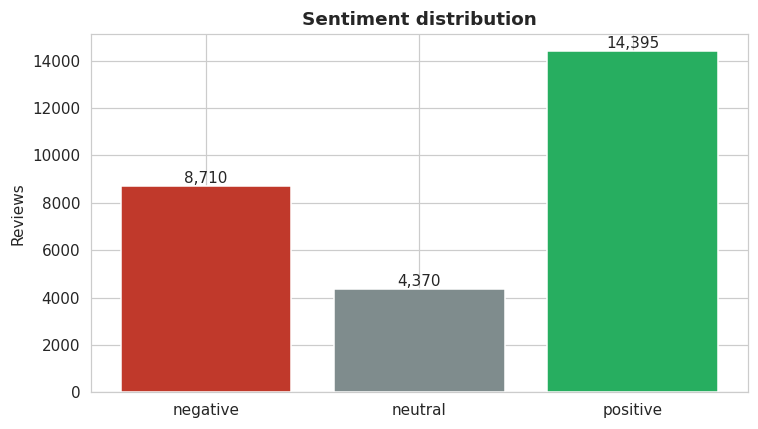

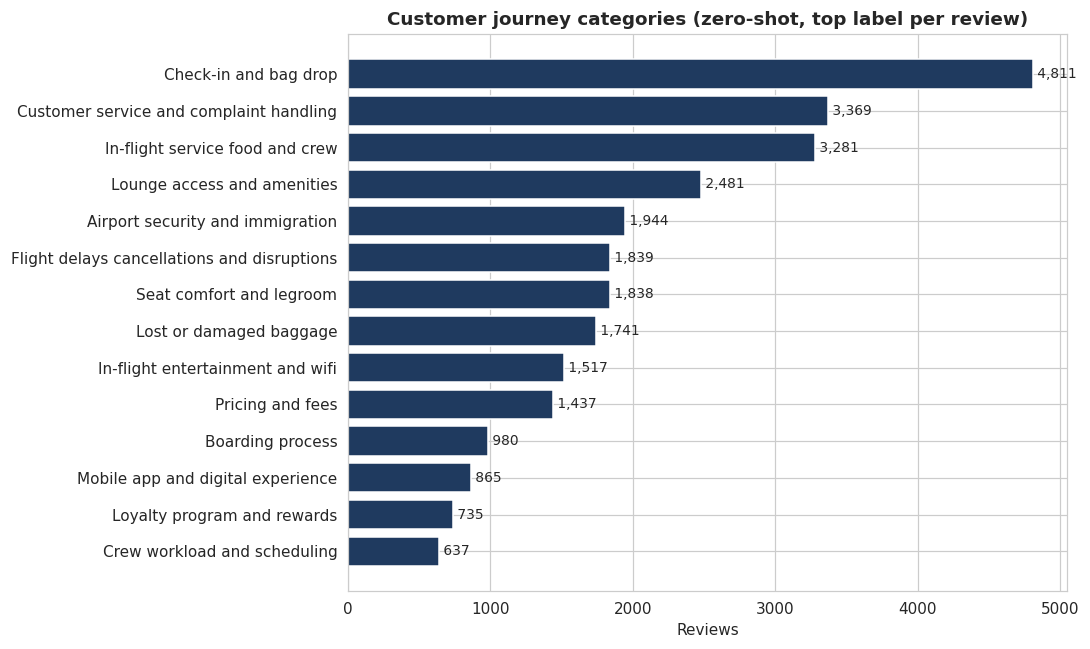

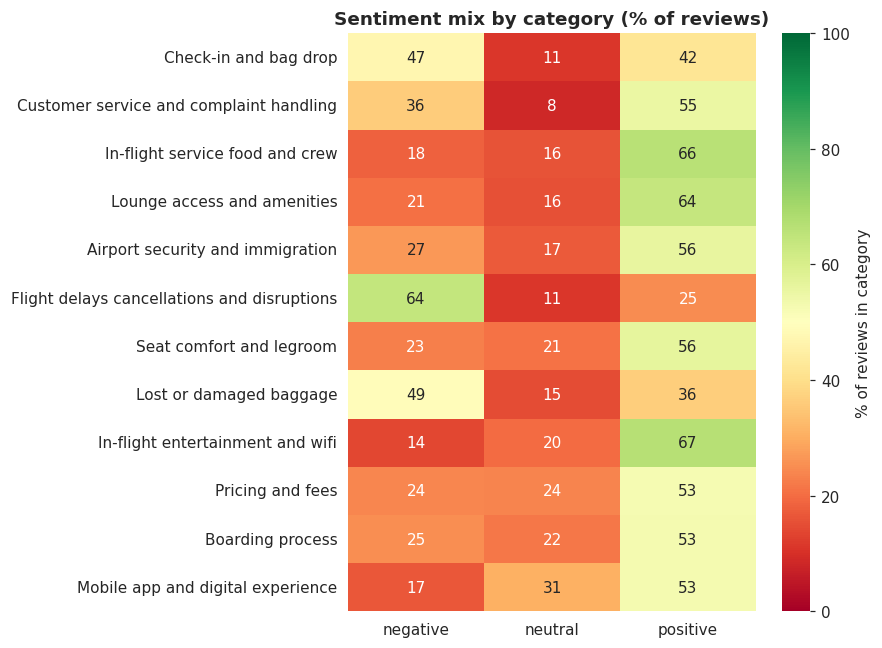

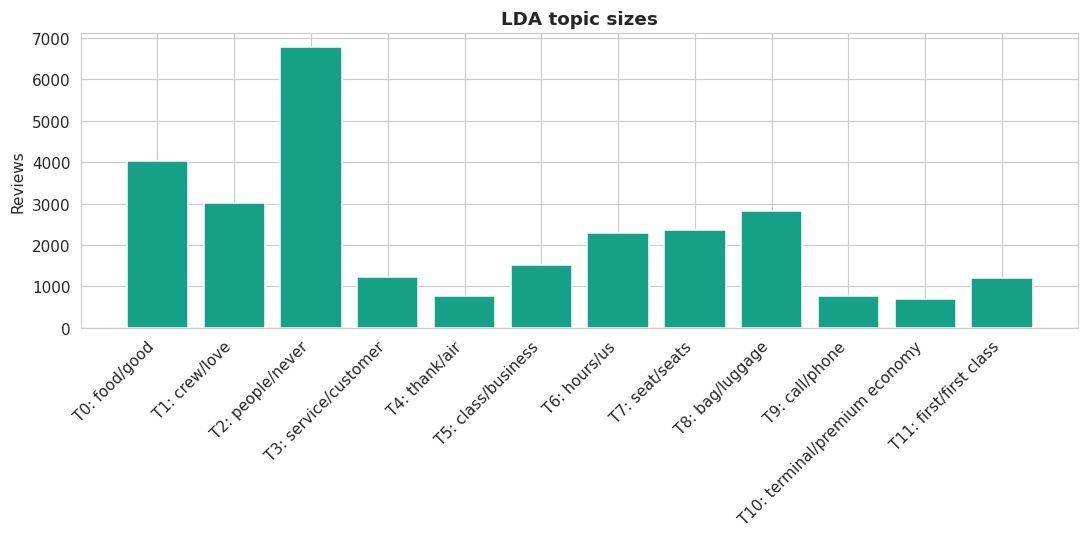

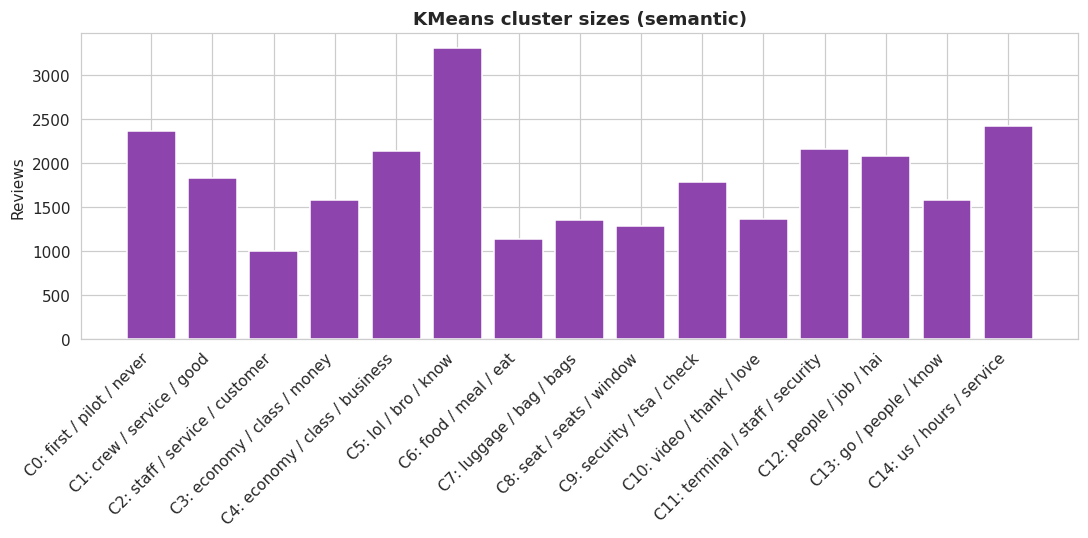

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- (a) Sentiment distribution ---
fig, ax = plt.subplots(figsize=(7, 4))
order = ["negative", "neutral", "positive"]
colors = {"negative": "#c0392b", "neutral": "#7f8c8d", "positive": "#27ae60"}
counts = df["sentiment_label"].value_counts().reindex(order, fill_value=0)
ax.bar(counts.index, counts.values, color=[colors[k] for k in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)
ax.set_title("Sentiment distribution", weight="bold")
ax.set_ylabel("Reviews")
plt.tight_layout(); plt.show()

# --- (b) Zero-shot category counts (if enabled) ---
if df["zs_top_category"].astype(str).str.len().sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    cat_counts = df["zs_top_category"].value_counts().head(15)
    ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color="#1F3A5F")
    for i, v in enumerate(cat_counts.values[::-1]):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    ax.set_title("Customer journey categories (zero-shot, top label per review)", weight="bold")
    ax.set_xlabel("Reviews")
    plt.tight_layout(); plt.show()

    # --- (c) Sentiment × category heatmap ---
    pivot = (df.groupby(["zs_top_category", "sentiment_label"]).size()
               .unstack(fill_value=0).reindex(columns=order, fill_value=0))
    pivot["total"] = pivot.sum(axis=1)
    pivot = pivot.sort_values("total", ascending=False).head(12).drop(columns=["total"])
    pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pct, annot=True, fmt=".0f", cmap="RdYlGn",
                cbar_kws={"label": "% of reviews in category"},
                vmin=0, vmax=100, ax=ax)
    ax.set_title("Sentiment mix by category (% of reviews)", weight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.tight_layout(); plt.show()

# --- (d) LDA topic sizes ---
fig, ax = plt.subplots(figsize=(10, 5))
topic_sizes = df["lda_topic"].value_counts().sort_index()
labels = [f"T{k}: {topic_keywords[k][0]}/{topic_keywords[k][1]}" for k in topic_sizes.index]
ax.bar(labels, topic_sizes.values, color="#16a085")
ax.set_title("LDA topic sizes", weight="bold")
ax.set_ylabel("Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

# --- (e) KMeans cluster sizes ---
if df["km_cluster"].max() >= 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    cl_sizes = df["km_cluster"].value_counts().sort_index()
    labels = [f"C{c}: {cluster_labels.get(c, '')[:30]}" for c in cl_sizes.index]
    ax.bar(labels, cl_sizes.values, color="#8e44ad")
    ax.set_title("KMeans cluster sizes (semantic)", weight="bold")
    ax.set_ylabel("Reviews")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()


In [13]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_XLSX = "/content/data/flying_reviews_categorized.xlsx"
os.makedirs("/content/data", exist_ok=True)

EXCEL_LIMIT = 32000
def _safe(v):
    if pd.isna(v) or v is None: return ""
    if isinstance(v, (int, float, bool)): return v
    s = str(v)
    return s if len(s) <= EXCEL_LIMIT else s[:EXCEL_LIMIT] + " ...[truncated]"

HEADER_FILL = PatternFill("solid", start_color="1F3A5F", end_color="1F3A5F")
HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=11)
BODY_FONT   = Font(name="Arial", size=10)
SECTION_FONT = Font(name="Arial", bold=True, size=12, color="1F3A5F")

WIDTH_HINTS = {
    "source":10, "source_target":24, "source_target_type":16,
    "stakeholder_hint":14, "title":34, "rating":8, "verified":9,
    "traveller_type":16, "seat_type":14, "route":24,
    "country":18, "author":18, "date":20, "score":8,
    "text":80, "text_clean":80, "url":40,
    "sentiment_compound":12, "sentiment_label":11,
    "zs_top_category":24, "zs_top_score":10, "zs_all_categories":40,
    "lda_topic":8, "lda_top_score":10, "lda_topic_label":28,
    "km_cluster":8, "km_cluster_label":28,
}

def _write_df(ws, df_, wrap_col=None):
    if df_.empty:
        ws["A1"] = "(no data)"; ws["A1"].font = BODY_FONT; return
    cols = list(df_.columns)
    for j, c in enumerate(cols, start=1):
        cell = ws.cell(row=1, column=j, value=c)
        cell.font = HEADER_FONT; cell.fill = HEADER_FILL
        cell.alignment = Alignment(horizontal="left", vertical="center")
    for i, (_, row) in enumerate(df_.iterrows(), start=2):
        for j, c in enumerate(cols, start=1):
            cell = ws.cell(row=i, column=j, value=_safe(row[c]))
            cell.font = BODY_FONT
            if c == wrap_col:
                cell.alignment = Alignment(wrap_text=True, vertical="top")
            else:
                cell.alignment = Alignment(vertical="top")
    for j, c in enumerate(cols, start=1):
        ws.column_dimensions[get_column_letter(j)].width = WIDTH_HINTS.get(c, 16)
    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

# --- Build outputs ---
wb = Workbook(); wb.remove(wb.active)

# Sheet 1: All reviews with tags
print("Writing 'All Reviews + Tags'...")
keep_cols = [c for c in [
    "source","source_target","source_target_type","stakeholder_hint",
    "rating","traveller_type","route","country","date",
    "sentiment_compound","sentiment_label",
    "zs_top_category","zs_top_score","zs_all_categories",
    "lda_topic","lda_topic_label","lda_top_score",
    "km_cluster","km_cluster_label",
    "text_clean",
] if c in df.columns]
ws = wb.create_sheet("All Reviews + Tags")
_write_df(ws, df[keep_cols], wrap_col="text_clean")

# Sheet 2: Category × sentiment pivot
if "zs_top_category" in df.columns and df["zs_top_category"].astype(str).str.len().sum() > 0:
    print("Writing 'By Category'...")
    pivot = (df.groupby(["zs_top_category", "sentiment_label"])
               .size().unstack(fill_value=0))
    for c in ["negative", "neutral", "positive"]:
        if c not in pivot.columns: pivot[c] = 0
    pivot = pivot[["negative","neutral","positive"]]
    pivot["total"] = pivot.sum(axis=1)
    pivot["pct_negative"] = (pivot["negative"] / pivot["total"]).round(3)
    pivot["priority_score"] = (pivot["total"] * pivot["pct_negative"]).round(1)
    pivot = pivot.sort_values("priority_score", ascending=False).reset_index()
    pivot.columns = ["Category","Negative","Neutral","Positive","Total","% Negative","Priority"]
    ws = wb.create_sheet("By Category")
    _write_df(ws, pivot)

# Sheet 3: LDA topics
print("Writing 'LDA Topics'...")
lda_summary = []
for k, words in topic_keywords.items():
    sz = int((df["lda_topic"] == k).sum())
    avg_sent = float(df.loc[df["lda_topic"] == k, "sentiment_compound"].mean()) if sz else 0
    lda_summary.append({
        "Topic ID": k,
        "Size": sz,
        "Avg sentiment": round(avg_sent, 3),
        "Top keywords (15)": ", ".join(words),
    })
lda_summary = pd.DataFrame(lda_summary).sort_values("Size", ascending=False)
ws = wb.create_sheet("LDA Topics")
_write_df(ws, lda_summary)

# Sheet 4: KMeans clusters
if df["km_cluster"].max() >= 0:
    print("Writing 'KMeans Clusters'...")
    km_summary = []
    for cid, label in cluster_labels.items():
        sz = int((df["km_cluster"] == cid).sum())
        avg_sent = float(df.loc[df["km_cluster"] == cid, "sentiment_compound"].mean()) if sz else 0
        # 2 example texts per cluster
        ex = df.loc[df["km_cluster"] == cid, "text_clean"].head(2).tolist()
        km_summary.append({
            "Cluster ID": cid,
            "Size": sz,
            "Label": label,
            "Avg sentiment": round(avg_sent, 3),
            "Example 1": (ex[0][:300] if ex else ""),
            "Example 2": (ex[1][:300] if len(ex) > 1 else ""),
        })
    km_summary = pd.DataFrame(km_summary).sort_values("Size", ascending=False)
    ws = wb.create_sheet("KMeans Clusters")
    _write_df(ws, km_summary)

# Sheet 5: Top 100 most negative
print("Writing 'Top Negative'...")
top_neg = df.sort_values("sentiment_compound").head(100)[
    [c for c in keep_cols if c in df.columns]
]
ws = wb.create_sheet("Top Negative")
_write_df(ws, top_neg, wrap_col="text_clean")

wb.save(OUTPUT_XLSX)
size_mb = os.path.getsize(OUTPUT_XLSX) / (1024 * 1024)
print(f"\nSaved -> {OUTPUT_XLSX} ({size_mb:.1f} MB)")
print(f"Sheets: {wb.sheetnames}")


Writing 'All Reviews + Tags'...
Writing 'By Category'...
Writing 'LDA Topics'...
Writing 'KMeans Clusters'...
Writing 'Top Negative'...

Saved -> /content/data/flying_reviews_categorized.xlsx (6.8 MB)
Sheets: ['All Reviews + Tags', 'By Category', 'LDA Topics', 'KMeans Clusters', 'Top Negative']


In [14]:
from google.colab import files
files.download(OUTPUT_XLSX)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>